In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [10]:
student_performance = fetch_ucirepo(id=320)
X = student_performance.data.features
y = student_performance.data.targets
df = pd.concat([X, y], axis=1)
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [11]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [12]:
print(df.isnull().sum())
print(df.duplicated().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
0


In [13]:
df = df.drop_duplicates()
df = df.dropna()

print(df.isnull().sum())
print(df.shape)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
(649, 33)


In [14]:
print(df.dtypes)

df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.dtypes)

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15

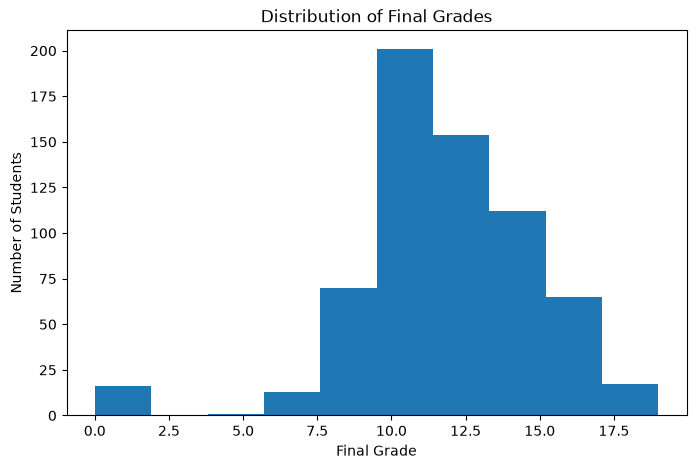

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["G3"], bins=10)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

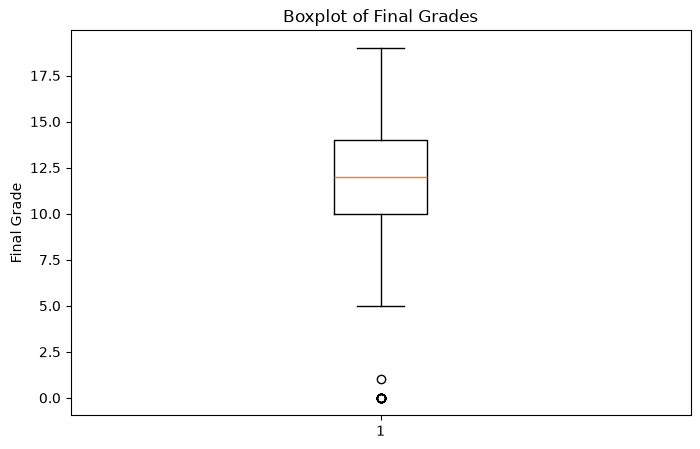

In [16]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["G3"])
plt.ylabel("Final Grade")
plt.title("Boxplot of Final Grades")
plt.show()

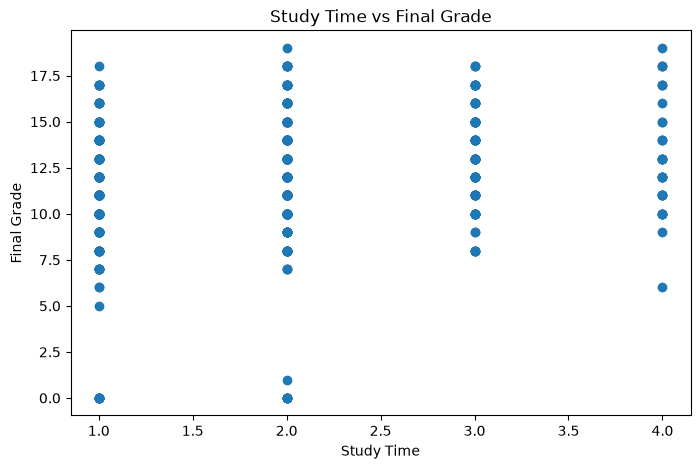

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df["studytime"], df["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")
plt.show()

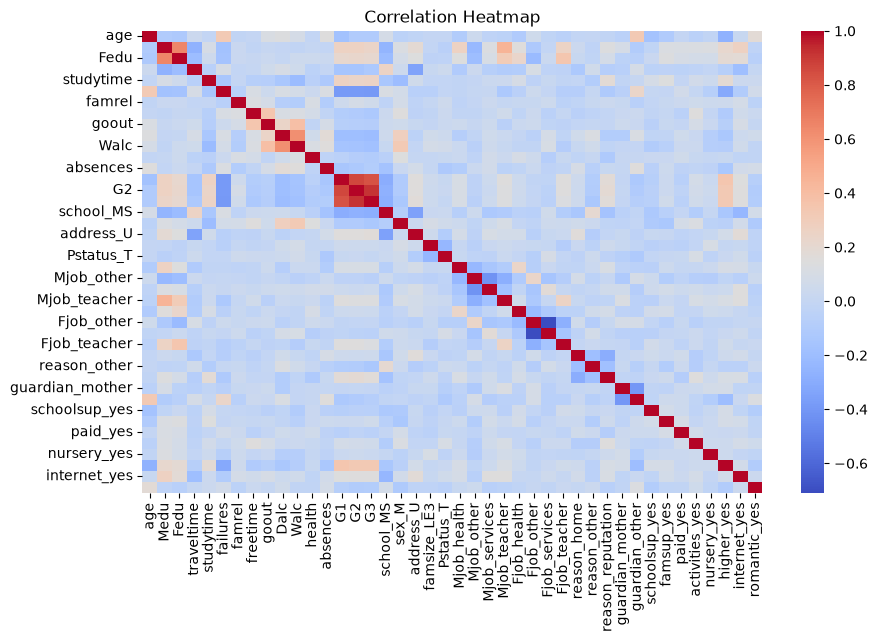

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

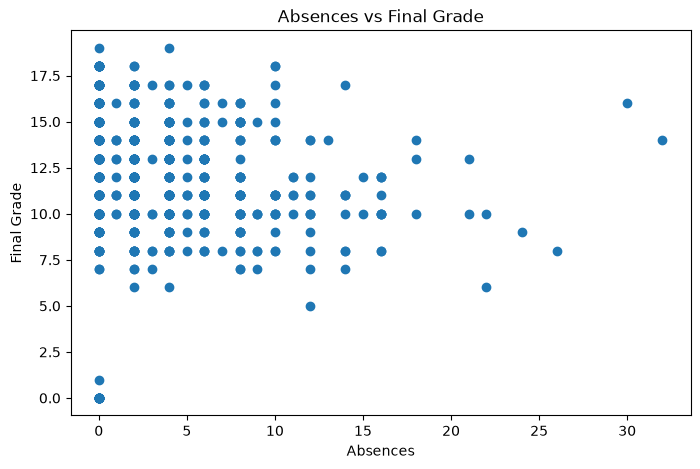

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df["absences"], df["G3"])
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")
plt.show()

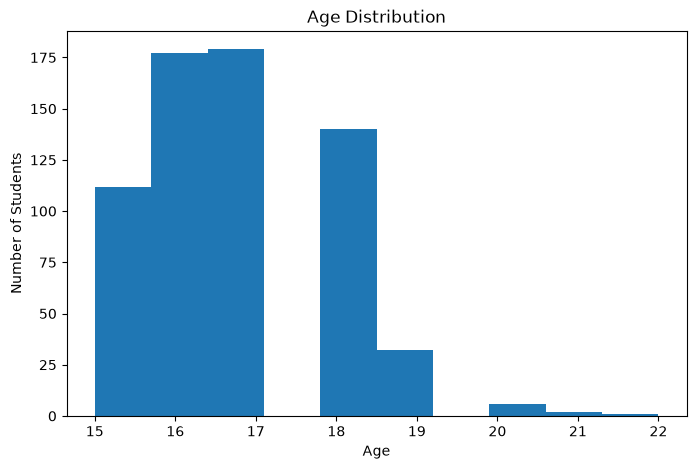

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Age Distribution")
plt.show()

In [21]:
df["studytime"] = (df["studytime"] - df["studytime"].min()) / (df["studytime"].max() - df["studytime"].min())
df["absences"] = (df["absences"] - df["absences"].min()) / (df["absences"].max() - df["absences"].min())

print(df[["studytime", "absences"]].head())
print(df.describe())

   studytime  absences
0   0.333333    0.1250
1   0.333333    0.0625
2   0.333333    0.1875
3   0.666667    0.0000
4   0.333333    0.0000
              age        Medu        Fedu  traveltime   studytime    failures  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean    16.744222    2.514638    2.306626    1.568567    0.310221    0.221880   
std      1.218138    1.134552    1.099931    0.748660    0.276503    0.593235   
min     15.000000    0.000000    0.000000    1.000000    0.000000    0.000000   
25%     16.000000    2.000000    1.000000    1.000000    0.000000    0.000000   
50%     17.000000    2.000000    2.000000    1.000000    0.333333    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    0.333333    0.000000   
max     22.000000    4.000000    4.000000    4.000000    1.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  649.000000  649.000000  649.000000  649.0000